In [2]:
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
from scipy import stats

### Table 4-22

In [3]:
df_t22 = pd.DataFrame({
    'treatment': np.repeat([1,2,3,4],4),
    'block': np.tile([1,2,3,4],4),
    'r_time': [73,74,np.nan,71,np.nan,75,67,72,73,75,68,np.nan,75,np.nan,72,75]
})

In [4]:
mask_t22 = ~df_t22['r_time'].isna()

In [5]:
df_t22['ave'] = df_t22['r_time'].mean()
df_t22['b_ave'] = df_t22.groupby('block')['r_time'].transform('mean')
df_t22['b_dev'] = df_t22['b_ave'] - df_t22['ave']
df_t22['t_ave'] = df_t22.groupby('treatment')['r_time'].transform('mean') 
df_t22['t_dev'] = df_t22['t_ave'] - df_t22['ave']

In [6]:
# sum of squares of block deviations (unadjusted)
(df_t22[mask_t22]['b_dev']**2).sum()

np.float64(55.0000000000001)

In [7]:
# sum of squares of treatment deviations (unadjusted)
(df_t22[mask_t22]['t_dev']**2).sum()

np.float64(11.666666666666705)

In [8]:
# sum of squares of treatment deviations (adjusted)
((df_t22[mask_t22].groupby('treatment')[['r_time', 'b_ave']].transform('mean').diff(axis=1)['b_ave']*3)**2).sum()/8

np.float64(22.749999999999915)

In [9]:
# sum of squares of block deviations (adjusted)
((df_t22[mask_t22].groupby('block')[['r_time', 't_ave']].transform('mean').diff(axis=1)['t_ave']*3)**2).sum()/8

np.float64(66.08333333333336)

In [10]:
# Least squares estimation of parameters
df_t22_ls = pd.get_dummies(df_t22[mask_t22][['treatment', 'block', 'r_time']], columns=['treatment', 'block'], dtype=int)

In [11]:
X_22 = np.concat((np.ones((12,1)), df_t22_ls.iloc[:,-8:].to_numpy()), axis=1)
y_22 = df_t22_ls[['r_time']].to_numpy()
C_22 = np.array([
    [0,1,1,1,1,0,0,0,0],
    [0,0,0,0,0,1,1,1,1]
]) # constrains
X_22, y_22, C_22

(array([[1., 1., 0., 0., 0., 1., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 1., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0., 1.],
        [1., 0., 1., 0., 0., 0., 1., 0., 0.],
        [1., 0., 1., 0., 0., 0., 0., 1., 0.],
        [1., 0., 1., 0., 0., 0., 0., 0., 1.],
        [1., 0., 0., 1., 0., 1., 0., 0., 0.],
        [1., 0., 0., 1., 0., 0., 1., 0., 0.],
        [1., 0., 0., 1., 0., 0., 0., 1., 0.],
        [1., 0., 0., 0., 1., 1., 0., 0., 0.],
        [1., 0., 0., 0., 1., 0., 0., 1., 0.],
        [1., 0., 0., 0., 1., 0., 0., 0., 1.]]),
 array([[73.],
        [74.],
        [71.],
        [75.],
        [67.],
        [72.],
        [73.],
        [75.],
        [68.],
        [75.],
        [72.],
        [75.]]),
 array([[0, 1, 1, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 1, 1]]))

In [12]:
theta_22 = np.linalg.solve(
    
    np.block([
    [X_22.T@(X_22), C_22.T],
    [C_22, np.zeros((2,2))]]
),
np.concatenate((X_22.T@(y_22), np.array([[0],[0]])))
)
theta_22

array([[ 7.25000000e+01],
       [-1.12500000e+00],
       [-8.75000000e-01],
       [-5.00000000e-01],
       [ 2.50000000e+00],
       [ 8.75000000e-01],
       [ 3.00000000e+00],
       [-3.87500000e+00],
       [-3.89445420e-16],
       [ 0.00000000e+00],
       [ 4.37150316e-16]])

In [13]:
np.block([
    [X_22.T@(X_22), C_22.T],
    [C_22, np.zeros((2,2))]]
)

array([[12.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  0.,  0.],
       [ 3.,  3.,  0.,  0.,  0.,  1.,  1.,  0.,  1.,  1.,  0.],
       [ 3.,  0.,  3.,  0.,  0.,  0.,  1.,  1.,  1.,  1.,  0.],
       [ 3.,  0.,  0.,  3.,  0.,  1.,  1.,  1.,  0.,  1.,  0.],
       [ 3.,  0.,  0.,  0.,  3.,  1.,  0.,  1.,  1.,  1.,  0.],
       [ 3.,  1.,  0.,  1.,  1.,  3.,  0.,  0.,  0.,  0.,  1.],
       [ 3.,  1.,  1.,  1.,  0.,  0.,  3.,  0.,  0.,  0.,  1.],
       [ 3.,  0.,  1.,  1.,  1.,  0.,  0.,  3.,  0.,  0.,  1.],
       [ 3.,  1.,  1.,  0.,  1.,  0.,  0.,  0.,  3.,  0.,  1.],
       [ 0.,  1.,  1.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  1.,  1.,  1.,  1.,  0.,  0.]])

In [14]:
np.concatenate((X_22.T@(y_22), np.array([[0],[0]])))

array([[870.],
       [218.],
       [214.],
       [216.],
       [222.],
       [221.],
       [224.],
       [207.],
       [218.],
       [  0.],
       [  0.]])

In [15]:
N_22 = df_t22[['treatment', 'block', 'r_time']].groupby(['treatment', 'block']).apply(pd.DataFrame).droplevel(2).unstack().isna().astype(int).to_numpy()
r_22 = 3
k_22 = 3

Ct_22 = r_22*np.eye(4) - (1/k_22)*N_22.dot(N_22.T)

theta_22[1:5].T.dot(Ct_22).dot(theta_22[1:5])

array([[22.75]])

### Problem 1
#### Apparently the new edition of this book has more problems related to using software for analysis
| Source | DF | SS | MS | F | P |
|-|-|-|-|-|-|
| Treatment | 4 | 1010.56 | 252.64 | 29.84 | 3.545e-8 |
| Block | 5 | 323.82 | 64.765 | 7.65 | 0.00037 |
| Error | 20 | 169.33 | 8.4665 |
| Total | 29 | 1503.71 |

In [16]:
stats.f.sf(29.84, dfn = 4, dfd=20), stats.f.sf(7.65, dfn = 5, dfd=20) # no significant difference btw treatments or blocks

(np.float64(3.544847524281011e-08), np.float64(0.0003687205421017092))

### Problem 2
| Source | DF | SS | MS | F | P |
|-|-|-|-|-|-|
| Factor | 4 | 987.72 | 246.93 | 46.36 | 7.67e-9 |
| Block | 5 | 80.00 | 16 | 3.00 | 0.04 |
| Error | 20 | 106.52 | 5.326 |
| Total | 29 | 1174.24 |

In [17]:
stats.f.sf(46.36, dfn = 4, dfd=20), stats.f.sf(3, dfn = 5, dfd=20) # no significant difference btw treatments or blocks

(np.float64(7.666521780041871e-10), np.float64(0.03520133745266663))

### Problem 1

In [37]:
df_01 = pd.DataFrame({
    'chemical': np.repeat(np.arange(4)+1, 5),
    'bolt': np.tile(np.arange(5)+1,4),
    'strength': [73,68,74,71,67,73,67,75,72,70,75,68,78,73,68,73,71,75,75,69]
})

In [38]:
df_01['ave'] = df_01.strength.mean()
df_01['residual'] = df_01['strength'] - df_01['ave'] 
df_01['chemical_ave'] = df_01.groupby('chemical')['strength'].transform('mean')
df_01['chemical_dev'] = df_01['chemical_ave'] - df_01['ave']
df_01['bolt_ave'] = df_01.groupby('bolt')['strength'].transform('mean')
df_01['bolt_dev'] = df_01['bolt_ave'] - df_01['ave']

In [39]:
ss_total_01 = (df_01['residual']**2).sum()

sst_01 = (df_01['chemical_dev']**2).sum()
dft_01 = 3
mst_01 = sst_01/dft_01

ssb_01 = (df_01['bolt_dev']**2).sum()
dfb_01 = 4
msb_01 = ssb_01/dft_01

sse_01 = ss_total_01 - sst_01 - ssb_01
dfe_01 = 12
mse_01 = sse_01/dfe_01

ft_01 = mst_01 / mse_01
pt_01 = stats.f.sf(ft_01, dfn=dft_01, dfd=dfe_01)

fb_01 = msb_01 / mse_01
pb_01 = stats.f.sf(fb_01, dfn=dfb_01, dfd=dfe_01)

ft_01, pt_01, fb_01, pb_01

(np.float64(2.3761467889908365),
 np.float64(0.12114447013105309),
 np.float64(28.807339449541345),
 np.float64(4.529505503174605e-06))

In [40]:
print(f'The f statistic and p value for treatments are {ft_01.round(3)} and {pt_01.round(3)}. No significant difference among different chemicals.')

The f statistic and p value for treatments are 2.376 and 0.121. No significant difference among different chemicals.


### Problem 2

In [147]:
def rcbd(df, treatment, block, result):
    '''
    Anava for the randomized complete block design (RCBD)
    df is a pandas dataframe includng one treatment column, one block column, and one result column
    It returns the statistics for the treatment, the treatment means, and the modified dataframe
    '''
    df = df.copy()
    df['ave'] = df[result].mean() # grand average
    df['t_ave'] = df.groupby(treatment)[result].transform('mean') # treatment average
    df['t_dev'] = df['t_ave'] - df['ave'] # treatment deviations from grand average
    df['b_ave'] = df.groupby(block)[result].transform('mean') # block average
    df['b_dev'] = df['b_ave'] - df['ave'] # block deviations from grand average
    df['residual'] = df[result] - (df['t_ave'] + df['b_ave'] - df['ave'])

    sst = (df['t_dev']**2).sum() # sum of squares of treatment deviations
    dft = df[treatment].nunique() - 1 # degrees of freedom of treatments
    mst = sst/dft # mean square of treatment deviations

    ssb = (df['b_dev']**2).sum() # sum of squares of block deviations
    dfb = df[block].nunique()-1 # degrees of freedom of blocks
    msb = ssb/dft # mean square of block deviations

    sse = (df['residual']**2).sum() # sum of squares of errors
    dfe = dft * dfb # degrees of freedom of errors
    mse = sse/dfe # mean square of erros

    ft = mst / mse # f statistic for treatment
    pt = stats.f.sf(ft, dfn=dft, dfd=dfe) # p value for treatment

    fb = msb / mse # f statistic for block
    pb = stats.f.sf(fb, dfn=dfb, dfd=dfe) # p value for block

    return {'f_statistic': ft, 'p_value': pt, 'mean_square_error': mse, 'degrees_of_freedom_error': dfe, 'n_blocks': df[block].nunique()}, df[[treatment, 't_ave']].drop_duplicates().reset_index(drop=True), df

In [148]:
def t_scatter_plot(stats_dict, t_ave, treatment):
    
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy import stats

    # data to generate the t distribution plot
    x_range = 5
    x = np.linspace(-x_range, x_range, 1001)
    y = stats.t.pdf(x, df=stats_dict['degrees_of_freedom_error'])
    plt.plot(x*np.sqrt(stats_dict['mean_square_error']/stats_dict['n_blocks'])+t_ave['t_ave'].mean(), y)
    plt.scatter(t_ave.t_ave, [0.01]*len(t_ave))
    [plt.text(x,y,s) for x,y,s in zip(t_ave.t_ave, [0.01]*len(t_ave), t_ave[treatment])]

    plt.show()

In [149]:
# test the function with example 4.1 and got the exactly the same results in the book
df_e01 = pd.DataFrame({
    't_tip': np.repeat(np.arange(4)+1, 4),
    'coupon': np.tile(np.arange(4)+1, 4),
    'result': [9.3,9.4,9.6,10.0,9.4,9.3,9.8,9.9,9.2,9.4,9.5,9.7,9.7,9.6,10.0,10.2]

})

In [150]:
stats_e01, t_ave_e01, df_e01 = rcbd(df_e01, 't_tip', 'coupon', 'result')

In [151]:
stats_e01, t_ave_e01

({'f_statistic': np.float64(14.437500000000059),
  'p_value': np.float64(0.0008712720711116527),
  'mean_square_error': np.float64(0.008888888888888875),
  'degrees_of_freedom_error': 9,
  'n_blocks': 4},
    t_tip  t_ave
 0      1  9.575
 1      2  9.600
 2      3  9.450
 3      4  9.875)

In [152]:
# test the function with problem 4.1 and got the exactly the same results as above
stats_01, t_ave_01, df_01 = rcbd(df_01, 'chemical', 'bolt', 'strength')

In [153]:
# problem 2
df_02 = pd.DataFrame({
    'solution': np.repeat(np.arange(1,4),4),
    'days': np.tile(np.arange(1,5),3),
    'result': [13,22,18,39,16,24,17,44,5,4,1,22]
})
stats_02, t_ave_02, df_02 = rcbd(df_02, treatment='solution', block='days', result='result')
stats_02, t_ave_02

({'f_statistic': np.float64(40.717041800643095),
  'p_value': np.float64(0.0003231554342489944),
  'mean_square_error': np.float64(8.638888888888888),
  'degrees_of_freedom_error': 6,
  'n_blocks': 4},
    solution  t_ave
 0         1  23.00
 1         2  25.25
 2         3   8.00)

### Problem 3

In [154]:
# data to generate the t distribution plot
r_03 = 5
x_03 = np.linspace(-r_03, r_03, 1001)
y_03 = stats.t.pdf(x_03, df=stats_02['degrees_of_freedom_error'])

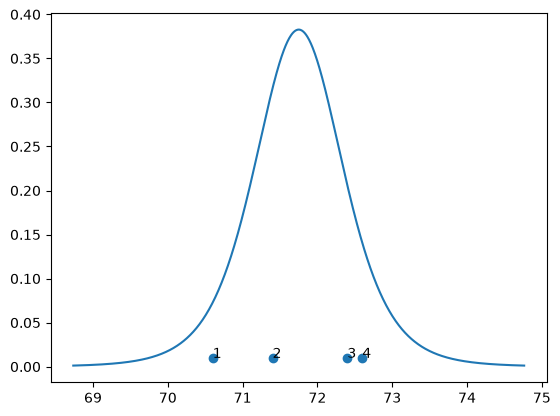

No significant differences btw each pairs, consistent with conclusion above


In [155]:
plt.plot(x_03*np.sqrt(stats_01['mean_square_error']/stats_01['n_blocks'])+t_ave_01['t_ave'].mean(), y_03)
plt.scatter(t_ave_01.t_ave, [0.01]*len(t_ave_01))
[plt.text(x,y,s) for x,y,s in zip(t_ave_01.t_ave, [0.01]*len(t_ave_01), t_ave_01.chemical)]

plt.show()
print('No significant differences btw each pairs, consistent with conclusion above')

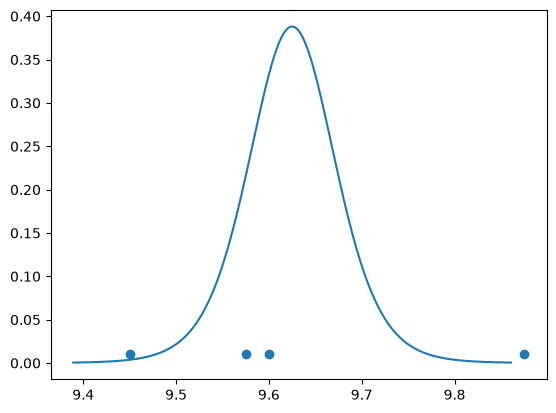

In [156]:
# example 4.1
r_e01 = 5
x_e01 = np.linspace(-r_e01, r_e01, 1001)
y_e01 = stats.t.pdf(x_e01, df=stats_e01['degrees_of_freedom_error'])

plt.plot(x_e01*np.sqrt(stats_e01['mean_square_error']/stats_e01['n_blocks']) + t_ave_e01.t_ave.mean(), y_e01)
plt.scatter(t_ave_e01.t_ave, [0.01]*len(t_ave_e01))
plt.show()

### Problem 4

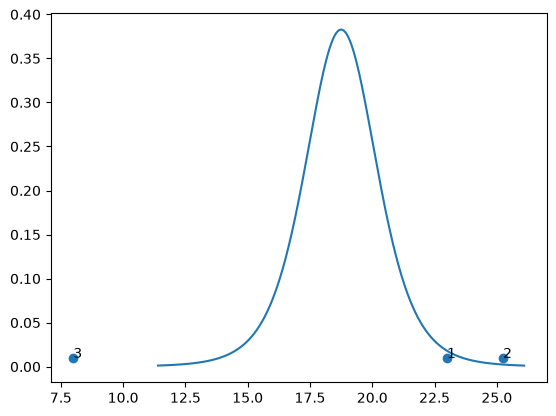

There is significant differences between 3 and (1,2).


In [157]:
# data to generate the t distribution plot
r_04 = 5
x_04 = np.linspace(-r_04, r_04, 1001)
y_04 = stats.t.pdf(x_04, df=stats_02['degrees_of_freedom_error'])
plt.plot(x_04*np.sqrt(stats_02['mean_square_error']/stats_02['n_blocks'])+t_ave_02['t_ave'].mean(), y_04)
plt.scatter(t_ave_02.t_ave, [0.01]*len(t_ave_02))
[plt.text(x,y,s) for x,y,s in zip(t_ave_02.t_ave, [0.01]*len(t_ave_02), t_ave_02.solution)]

plt.show()
print('There is significant differences between 3 and (1,2).')

### Problem 5

In [158]:
df_05 = pd.DataFrame({
    'nozzle': np.repeat(np.arange(1,6),6),
    'flux_v': np.tile([11.73,14.37,16.59,20.43,23.46,28.74],5),
    'shape_factor': [0.78,0.80,0.81,0.75,0.77,0.78,0.85,0.85,0.92,0.86,0.81,0.83,0.93,0.92,0.95,0.89,0.89,0.83,1.14,0.97,0.98,0.88,0.86,0.83,0.97,0.86,0.78,0.76,0.76,0.75]
})

In [159]:
stats_05, t_ave_05, df_05 = rcbd(df_05, 'nozzle', 'flux_v', 'shape_factor')
print(f'The nozzels affect the shape factor. The f statistic and p value are {stats_05['f_statistic'].round(3)} and {stats_05['p_value'].round(5)}')

The nozzels affect the shape factor. The f statistic and p value are 8.916 and 0.00027


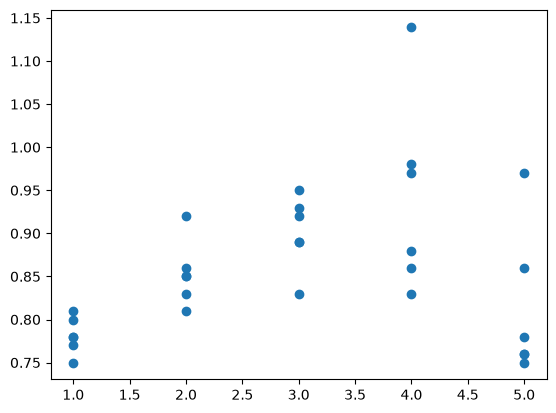

In [160]:
plt.scatter(df_05.nozzle, df_05.shape_factor) # The plot shows that nozzel type 1 and 5 are probably different with the rest
plt.show()

(<Figure size 640x480 with 1 Axes>, <Axes: >)

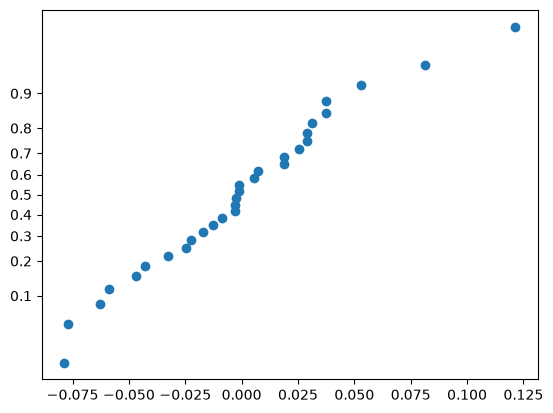

In [161]:
# analyze the residual and there is slight violation of normality
from normality_plot import normality_plot

normality_plot(df_05['shape_factor'] - (df_05.t_ave + df_05.b_ave - df_05.ave))

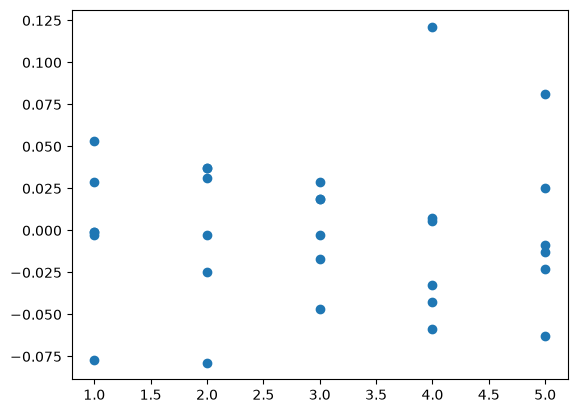

In [162]:
plt.scatter(df_05.nozzle, df_05['shape_factor'] - (df_05.t_ave + df_05.b_ave - df_05.ave)) # The plot shows that there is slight violation of normality
plt.show()

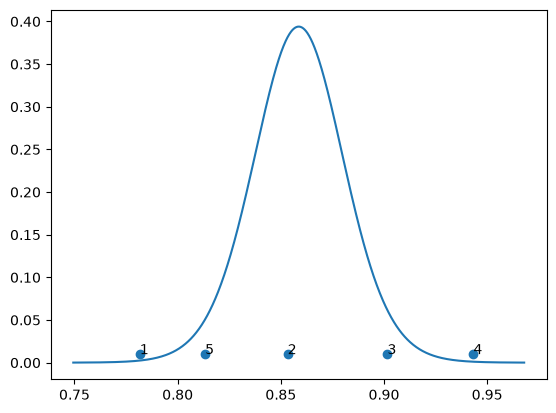

In [163]:
# (c) t distribution plot
t_scatter_plot(stats_05, t_ave_05, 'nozzle')

In [164]:
# (c) compare each pair with Duncan's test
se_t_05 = np.sqrt(stats_05['mean_square_error'] / df_05['flux_v'].nunique()) # the standard error for the treatment means

# caculate Duncan's protection alpha adjustment: adjusted_alpha = 1 - (1 - alpha)**(p - 1) where p is the number of treatments
# calculate the cumulated probability based on the adjusted alpha: 1 - adjusted_alpha = (1 - alpha)**(p - 1)

# find all r factors and the corresponding ranges with alpha=0.05
alpha_05 = 0.05
p_05 = []
lsr_05 = []
for p in range(2, df_05['nozzle'].nunique()+1):
    p_05.append(p)
    lsr_05.append((stats.studentized_range.ppf((1-alpha_05)**(p-1), k=p, df=stats_05['degrees_of_freedom_error']) * se_t_05).round(3))

# lsr_05

In [165]:
lsr_05

[np.float64(0.064), np.float64(0.068), np.float64(0.07), np.float64(0.071)]

In [166]:
# compare each pairs of treatments by their means

# find all pairs
nozzles = np.arange(1,6)
nozzle_pairs = []
from itertools import combinations
nozzle_pairs.extend(combinations(nozzles, 2))

nozzle_pair_diff = []
for nozzle_pair in nozzle_pairs:
    nozzle_pair_diff.append(np.abs(t_ave_05[t_ave_05['nozzle'].isin(nozzle_pair)]['t_ave'].diff().iloc[1]))

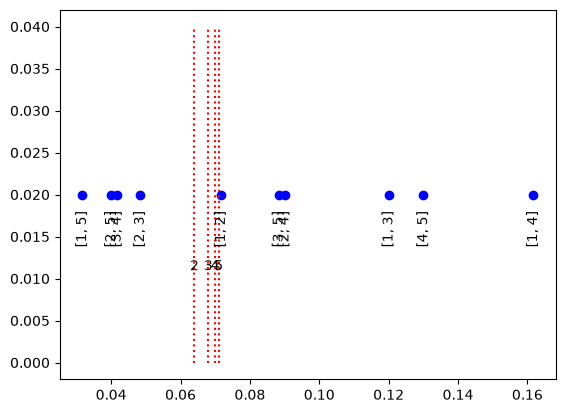

There are significant differences btw (1,2), (3,5), (2,4), (1,3), (4,5), and (1,4)


In [167]:
# plot the least significant ranges together with the treatment mean diffs
# plt.scatter(lsr_05, [0.01]*len(lsr_05), c='r')

[plt.plot([x]*1001, np.linspace(0,0.04,1001), c='r', linestyle=':') for x in lsr_05]

[plt.text(x,y,s, ha='center') for x,y,s in zip(lsr_05, [0.011]*len(lsr_05), p_05)]
plt.scatter(nozzle_pair_diff, [0.02]*len(nozzle_pair_diff), c='b')
[plt.text(x,y,[int(n) for n in s], ha='center', rotation=90, va='top') for x,y,s in zip(nozzle_pair_diff, [0.018]*len(nozzle_pair_diff), nozzle_pairs)]
plt.show()
print('There are significant differences btw (1,2), (3,5), (2,4), (1,3), (4,5), and (1,4)')

### Problem 6

In [175]:
df_06 = pd.DataFrame({
    'r_ctr': np.repeat(np.arange(1,5),6),
    't_period': np.tile(np.arange(1,7),4),
    'volt': [4.93,4.86,4.75,4.95,4.79,4.88,4.85,4.91,4.79,4.85,4.75,4.85,4.83,4.88,4.90,4.75,4.82,4.90,4.89,4.77,4.94,4.86,4.79,4.76],
    'v_std': [0.05,0.04,0.05,0.06,0.03,0.05,0.04,0.02,0.03,0.05,0.03,0.02,0.09,0.13,0.11,0.15,0.08,0.12,0.03,0.04,0.05,0.05,0.03,0.02]
})
df_06['log_v_std'] = -df_06['v_std'].apply(np.log)

In [176]:
# a. averge cell voltage analysis
stats_06a, t_ave_06a, df_06a = rcbd(df_06, 'r_ctr', 't_period', 'volt')
print(f'The f statistic and p value for the test is {stats_06a['f_statistic'].round(3)} and {stats_06a['p_value'].round(3)} (larger than the alpha 0.05). The choice of ratio control algorithm does not affect the average cell voltage')

The f statistic and p value for the test is 0.19 and 0.901 (larger than the alpha 0.05). The choice of ratio control algorithm does not affect the average cell voltage


In [177]:
# b. cell voltage std analysis using original data
stats_06b1, t_ave_06b1, df_06b1 = rcbd(df_06, 'r_ctr', 't_period', 'v_std')
print(f'The f statistic and p value for the test is {stats_06b1['f_statistic'].round(3)} and {stats_06b1['p_value'].round(8)} (smaller than the alpha 0.05). The choice of ratio control algorithm does affect the cell voltage standard deviation.')

The f statistic and p value for the test is 50.756 and 4e-08 (smaller than the alpha 0.05). The choice of ratio control algorithm does affect the cell voltage standard deviation.


In [178]:
# b. cell voltage std analysis
stats_06b2, t_ave_06b2, df_06b2 = rcbd(df_06, 'r_ctr', 't_period', 'log_v_std')
print(f'The f statistic and p value for the test is {stats_06b2['f_statistic'].round(3)} and {stats_06b2['p_value'].round(6)} (smaller than the alpha 0.05). The choice of ratio control algorithm does affect the cell voltage standard deviation.')

The f statistic and p value for the test is 33.257 and 1e-06 (smaller than the alpha 0.05). The choice of ratio control algorithm does affect the cell voltage standard deviation.


((<Figure size 640x480 with 1 Axes>, <Axes: >),
 (<Figure size 640x480 with 1 Axes>, <Axes: >),
 (<Figure size 640x480 with 1 Axes>, <Axes: >))

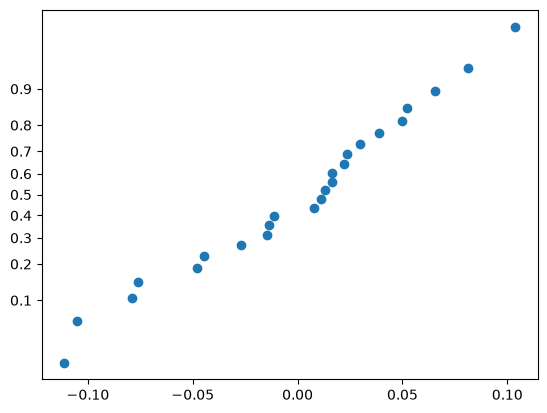

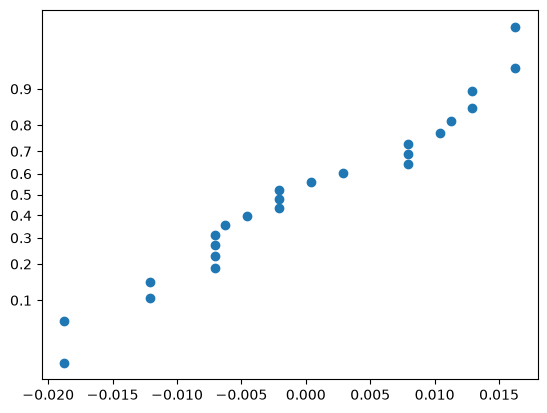

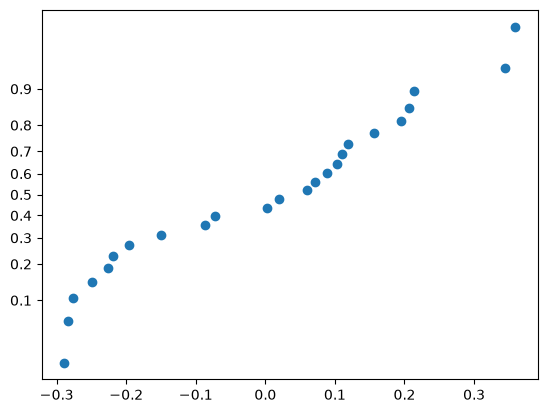

In [ ]:
# c. residual analysis by normality plot. The residuals of all three dataset show very mild violation of normality
normality_plot(df_06a['residual']), normality_plot(df_06b1['residual']), normality_plot(df_06b2['residual']), 

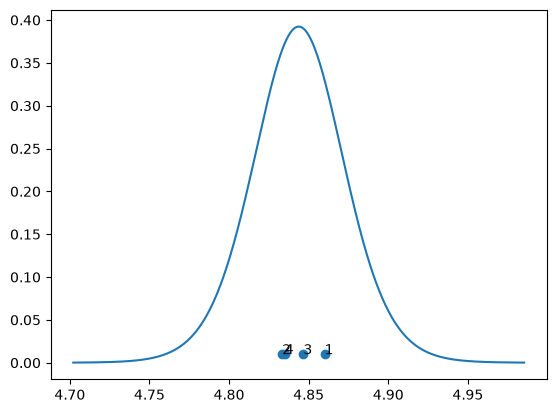

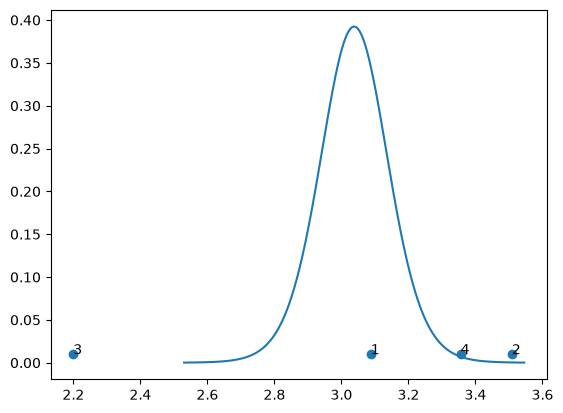

Since there is no significant difference in average voltage among different algorithms, I would choose the one with the lowest voltage standard deviation, algorithm 3 as shown in the plots above.


In [186]:
t_scatter_plot(stats_06a, t_ave_06a, 'r_ctr'), t_scatter_plot(stats_06b2, t_ave_06b2, 'r_ctr')
print('Since there is no significant difference in average voltage among different algorithms, I would choose the one with the lowest voltage standard deviation, algorithm 3 as shown in the plots above.')

tscatterplot

In [182]:
t_ave_06a

,r_ctr,t_ave
0,1,4.860000
1,2,4.833333
2,3,4.846667
3,4,4.835000
